# Dataset Exploration (HAM10000)

Coarse-To-Fine Hierarchy:
- `diagnosis_1` (e.g., Benign / Malignant / Indeterminate)
- `diagnosis_2` (mid-level groups)
- `diagnosis_3` (final class-label for training)


In [1]:
from pathlib import Path
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

random.seed(42)

In [2]:
PROJECT_ROOT = Path("..").resolve()
DATASET_DIR = PROJECT_ROOT / "data" / "raw"
META_PATH = DATASET_DIR / "metadata.csv"
metadata = pd.read_csv(META_PATH)

display_cols = [
    "isic_id",
    "lesion_id",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
    "age_approx",
    "sex",
    "anatom_site_general",
    "melanocytic",
]

styled = (
    metadata[display_cols]
    .head()
    .style
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
)
display(styled)


,isic_id,lesion_id,diagnosis_1,diagnosis_2,diagnosis_3,age_approx,sex,anatom_site_general,melanocytic
0,ISIC_0024306,IL_7252831,Benign,Benign melanocytic proliferations,Nevus,45.000000,male,nan,True
1,ISIC_0024307,IL_6125741,Benign,Benign melanocytic proliferations,Nevus,50.000000,male,lower extremity,True
2,ISIC_0024308,IL_3692653,Benign,Benign melanocytic proliferations,Nevus,55.000000,female,nan,True
3,ISIC_0024309,IL_0959663,Benign,Benign melanocytic proliferations,Nevus,40.000000,male,nan,True
4,ISIC_0024310,IL_8194852,Malignant,Malignant melanocytic proliferations (Melanoma),"Melanoma, NOS",60.000000,male,anterior torso,True


## Label Completeness Check

Verify that every image has a label for all three diagnosis levels.

In [3]:
diag_cols = ["diagnosis_1", "diagnosis_2", "diagnosis_3"]

completeness_data = []
for col in diag_cols:
    total = len(metadata)
    non_null = metadata[col].notna().sum()
    null = metadata[col].isna().sum()
    pct = non_null / total * 100
    completeness_data.append({
        "Column": col,
        "Total": total,
        "Non-Null": non_null,
        "Null": null,
        "Complete (%)": f"{pct:.1f}",
    })

completeness_df = pd.DataFrame(completeness_data)

styled = (
    completeness_df
    .style
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
    .hide(axis="index")
)
display(styled)

all_complete = all(metadata[col].notna().all() for col in diag_cols)
if all_complete:
    print("\nEvery image has a label for all three diagnosis levels.")
else:
    for col in diag_cols:
        n_missing = metadata[col].isna().sum()
        if n_missing > 0:
            print(f"{col}: {n_missing} images have no valid label.")


Column,Total,Non-Null,Null,Complete (%)
diagnosis_1,10015,10015,0,100.0
diagnosis_2,10015,10015,0,100.0
diagnosis_3,10015,9873,142,98.6


diagnosis_3: 142 images have no valid label.


## Key Dataset Statistics

In [4]:
imgs_per_lesion = metadata.groupby("lesion_id").size()

stats_data = [
    {"Metric": "Total images",                 "Value": len(metadata)},
    {"Metric": "Total unique lesions",          "Value": metadata["lesion_id"].nunique()},
    {"Metric": "Avg. images per lesion",        "Value": f"{imgs_per_lesion.mean():.2f}"},
    {"Metric": "Min images per lesion",         "Value": imgs_per_lesion.min()},
    {"Metric": "Max images per lesion",         "Value": imgs_per_lesion.max()},
    {"Metric": "Median images per lesion",      "Value": f"{imgs_per_lesion.median():.1f}"},
    {"Metric": "Unique diagnosis_1 classes",    "Value": metadata["diagnosis_1"].nunique()},
    {"Metric": "Unique diagnosis_2 classes",    "Value": metadata["diagnosis_2"].nunique()},
    {"Metric": "Unique diagnosis_3 classes",    "Value": metadata["diagnosis_3"].nunique()},
]

stats_df = pd.DataFrame(stats_data)

styled = (
    stats_df
    .style
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
    .hide(axis="index")
)
display(styled)


Metric,Value
Total images,10015
Total unique lesions,7470
Avg. images per lesion,1.34
Min images per lesion,1
Max images per lesion,6
Median images per lesion,1.0
Unique diagnosis_1 classes,3
Unique diagnosis_2 classes,8
Unique diagnosis_3 classes,7


## Class Distribution Bar Charts

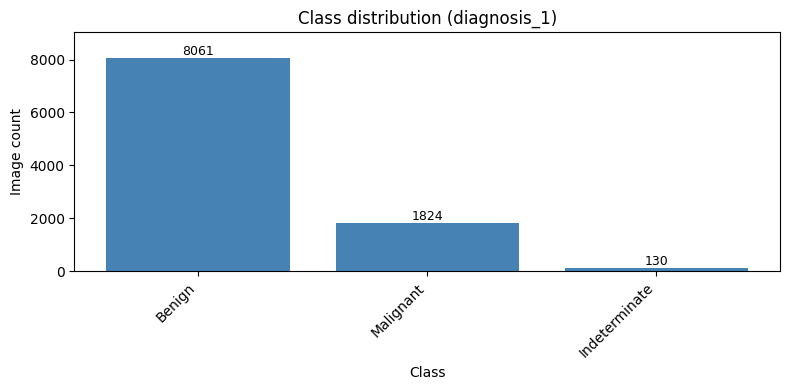

In [5]:
# Distribution of diagnosis_1 classes
counts = metadata["diagnosis_1"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(counts)), counts.values, color="steelblue")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45, ha="right")
ax.set_title("Class distribution (diagnosis_1)")
ax.set_ylabel("Image count")
ax.set_xlabel("Class")
ax.set_ylim(0, counts.max() * 1.12)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(val), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


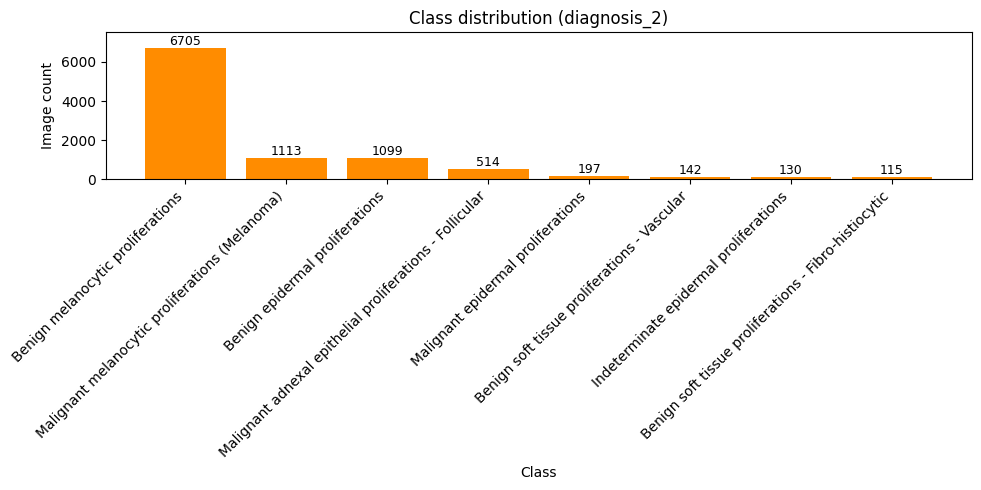

In [6]:
# Distribution of diagnosis_2 classes
counts = metadata["diagnosis_2"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(counts)), counts.values, color="darkorange")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45, ha="right")
ax.set_title("Class distribution (diagnosis_2)")
ax.set_ylabel("Image count")
ax.set_xlabel("Class")
ax.set_ylim(0, counts.max() * 1.12)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(val), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


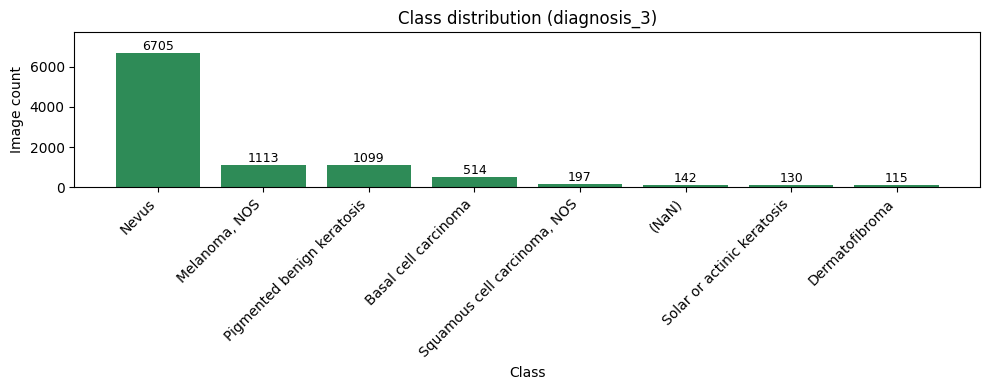

In [7]:
# Distribution of diagnosis_3 classes
counts = metadata["diagnosis_3"].fillna("(NaN)").value_counts(dropna=False).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(counts)), counts.values, color="seagreen")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45, ha="right")
ax.set_title("Class distribution (diagnosis_3)")
ax.set_ylabel("Image count")
ax.set_xlabel("Class")
ax.set_ylim(0, counts.max() * 1.15) 
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(val), ha="center", va="bottom", fontsize=9)
            
plt.tight_layout()
plt.show()

## Sample Images: All Pictures of One Lesion per Diagnosis

For each `diagnosis_3` class we randomly pick **one lesion** and show **all** its images.

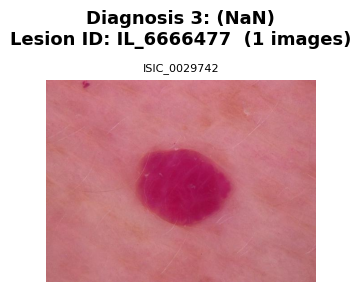

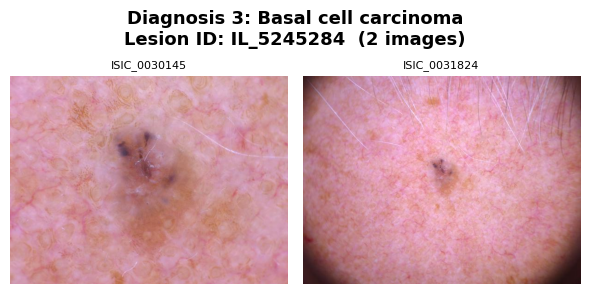

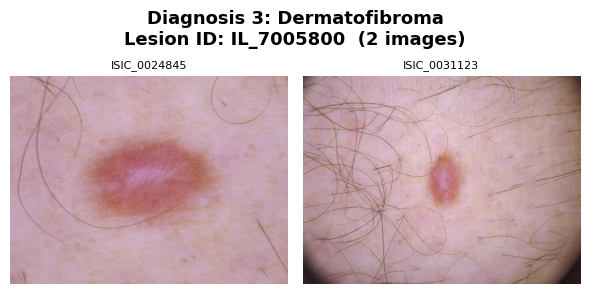

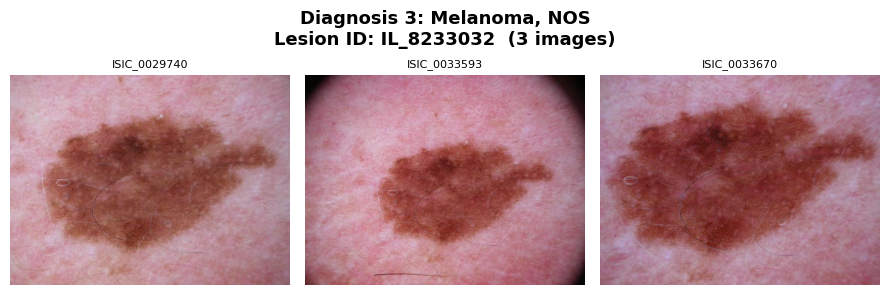

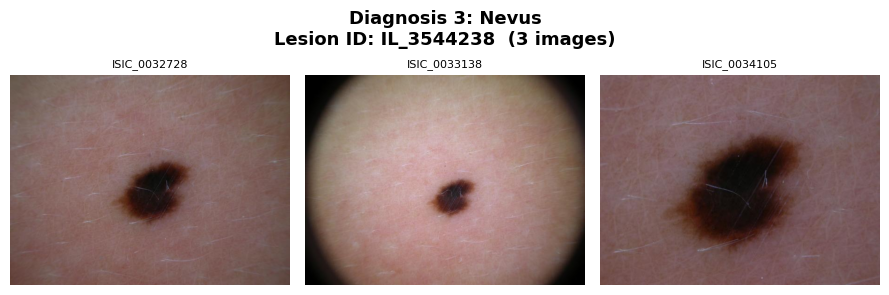

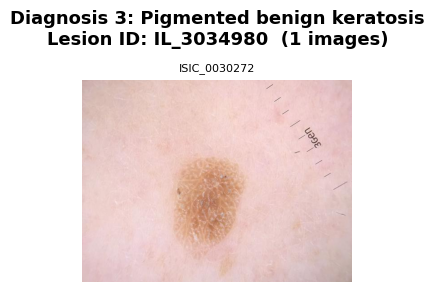

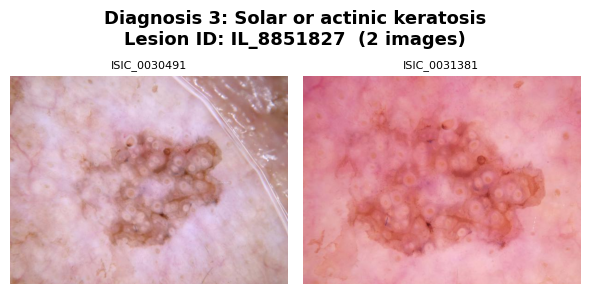

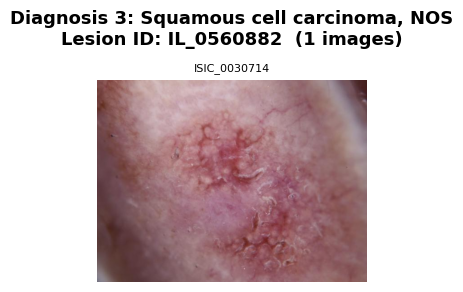

In [8]:
label_col = "diagnosis_3"


metadata_filled = metadata.copy()
metadata_filled[label_col] = metadata_filled[label_col].fillna("(NaN)")


for cls in sorted(metadata_filled[label_col].unique()):
    subset = metadata_filled[metadata_filled[label_col] == cls]
    
    # Pick one random lesion
    lesion = subset["lesion_id"].drop_duplicates().sample(1, random_state=42).iloc[0]
    lesion_imgs = subset[subset["lesion_id"] == lesion]

    n = len(lesion_imgs)
    cols = min(n, 6)
    rows = int(np.ceil(n / cols))
    
    # Handle the edge case where cols could be 0 (if n=0, though shouldn't happen here)
    if cols == 0:
        continue
        
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    if n == 1:
        axes = np.array([axes])
    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(
        f"Diagnosis 3: {cls}\nLesion ID: {lesion}  ({n} images)",
        fontsize=13, fontweight="bold"
    )

    for ax, (_, row) in zip(axes, lesion_imgs.iterrows()):
        img_path = DATASET_DIR / f"{row['isic_id']}.jpg"
        if img_path.exists():
            img = plt.imread(img_path)
            ax.imshow(img)
        ax.set_title(row["isic_id"], fontsize=8)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Diagnosis 3 Categories Grouped by their Diagnosis 2 Parents

In [9]:
df = pd.read_csv("../data/raw/metadata.csv")

crosstab = pd.crosstab(
      df["diagnosis_3"].fillna("(NaN)"),  
      df["diagnosis_2"].fillna("(NaN)"),  
      margins=True,
      margins_name="Total"
  )

crosstab = crosstab.drop("Total", axis=0)

col_order = [c for c in crosstab.columns if c != "Total"] + (["Total"] if "Total" in crosstab.columns else [])
crosstab = crosstab[col_order]

crosstab = crosstab.sort_values("Total", ascending=False)
crosstab = crosstab.reset_index()
crosstab = crosstab.rename(columns={"diagnosis_3": "Diagnosis 3"})

crosstab.style \
      .hide(axis="index") \
      .set_properties(subset=["Diagnosis 3"], **{"text-align": "left"}) \
      .set_table_styles([
          {"selector": "th.col_heading:first-child", "props": [("text-align", "left")]},
      ])


Diagnosis 3,Benign epidermal proliferations,Benign melanocytic proliferations,Benign soft tissue proliferations - Fibro-histiocytic,Benign soft tissue proliferations - Vascular,Indeterminate epidermal proliferations,Malignant adnexal epithelial proliferations - Follicular,Malignant epidermal proliferations,Malignant melanocytic proliferations (Melanoma),Total
Nevus,0,6705,0,0,0,0,0,0,6705
"Melanoma, NOS",0,0,0,0,0,0,0,1113,1113
Pigmented benign keratosis,1099,0,0,0,0,0,0,0,1099
Basal cell carcinoma,0,0,0,0,0,514,0,0,514
"Squamous cell carcinoma, NOS",0,0,0,0,0,0,197,0,197
(NaN),0,0,0,142,0,0,0,0,142
Solar or actinic keratosis,0,0,0,0,130,0,0,0,130
Dermatofibroma,0,0,115,0,0,0,0,0,115


# Benign, Malignant and Indeterminate Samples Grouped by Diagnosis 3


In [10]:
df = pd.read_csv("../data/raw/metadata.csv")

crosstab = pd.crosstab(
    [df["diagnosis_3"].fillna("(NaN)"), df["diagnosis_2"].fillna("(NaN)")],
    df["diagnosis_1"],
    margins=True,
    margins_name="Total"
)

# Remove the Total row at the very bottom
if "Total" in crosstab.index:
    crosstab = crosstab.drop("Total", axis=0)

# Sort the columns
col_order = [c for c in ["Benign", "Malignant", "Indeterminate", "Total"] if c in crosstab.columns]
crosstab = crosstab[col_order]
crosstab = crosstab.sort_values("Total", ascending=False)
crosstab = crosstab.reset_index()

# Rename the columns for a clean look
crosstab = crosstab.rename(columns={
    "diagnosis_3": "Diagnosis 3",
    "diagnosis_2": "Diagnosis 2"
})

# Display styling: left-align the first two text columns
crosstab.style \
    .hide(axis="index") \
    .set_properties(subset=["Diagnosis 3", "Diagnosis 2"], **{"text-align": "left"}) \
    .set_table_styles([
        {"selector": "th.col_heading:nth-child(1)", "props": [("text-align", "left")]},
        {"selector": "th.col_heading:nth-child(2)", "props": [("text-align", "left")]},
    ])


Diagnosis 3,Diagnosis 2,Benign,Malignant,Indeterminate,Total
Nevus,Benign melanocytic proliferations,6705,0,0,6705
"Melanoma, NOS",Malignant melanocytic proliferations (Melanoma),0,1113,0,1113
Pigmented benign keratosis,Benign epidermal proliferations,1099,0,0,1099
Basal cell carcinoma,Malignant adnexal epithelial proliferations - Follicular,0,514,0,514
"Squamous cell carcinoma, NOS",Malignant epidermal proliferations,0,197,0,197
(NaN),Benign soft tissue proliferations - Vascular,142,0,0,142
Solar or actinic keratosis,Indeterminate epidermal proliferations,0,0,130,130
Dermatofibroma,Benign soft tissue proliferations - Fibro-histiocytic,115,0,0,115
